In [1]:
import os
import sys
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns

import seqpro as sp

from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo
from tangermeme.seqlet import recursive_seqlets
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme, extract_loci

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [37]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile

In [42]:
os.chdir("/cellar/users/aklie/projects/igvf/ChromBetaNet")

In [43]:
path_out = "scratch/2025_06_22"

# Load genome

In [6]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [7]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load model

In [8]:
path_model = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/models/chrombpnet_nobias.h5"
model = BPNet.from_chrombpnet(path_model).cuda().eval()

# Load peaks

In [10]:
path_peaks = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/peaks/D15_merged_ENP_peaks.bed"
path_schema = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/5_peak_analysis/peak_calls/3-cyt_rna_celltype/snapatac2/SC.beta.narrowPeak.schema"
schema = pd.read_csv(path_schema, header=None, sep='\t')[0].tolist()  # convert schema to a list
peaks = pd.read_csv(path_peaks, header=None, sep='\t', names=schema)  # corrected to use schema

In [11]:
# Remove duplicate chrom start and end taking the highest q_value
peaks = peaks.sort_values('q_value', ascending=False).drop_duplicates(subset=['chrom', 'start', 'end'])
peaks

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak
7,chr1,633840,634204,.,1000,.,40.609467,109236.929688,109228.906250,193
109643,chr17,22521248,22521557,.,1000,.,43.419971,34642.917969,34635.835938,150
6,chr1,629813,630101,.,1000,.,8.402439,10337.239258,10330.491211,142
3021,chr1,16612947,16614053,.,1000,.,25.223841,7114.754395,7108.110352,661
112224,chr17,43251568,43251928,.,1000,.,46.463974,6077.647949,6071.098633,146
...,...,...,...,...,...,...,...,...,...,...
125611,chr18,78739087,78739330,.,13,.,1.479915,2.706340,1.309857,94
108848,chr17,17019608,17019854,.,13,.,1.675393,2.705390,1.308933,129
119139,chr18,7063745,7064068,.,13,.,1.617133,2.703760,1.307358,73
267882,chr8,144538109,144538392,.,13,.,1.732673,2.701570,1.305214,185


In [14]:
X, signals = extract_loci(
    loci=peaks,
    sequences=genome_fasta,
    signals=["/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/auxiliary/data_unstranded.bw"],
    chroms=["chr1", "chr3", "chr6"],
    ignore=list('QWERYUIOPSDFHJKLZXVBNM'),
)

# Counts performance

In [ ]:
count_wrapper = CountWrapper(model).cuda().eval()

In [15]:
y_0 = predict(
    model=count_wrapper,
    X=X,
    verbose=True,
)

100%|██████████| 1537/1537 [00:50<00:00, 30.37it/s]


In [20]:
y_0_np = y_0.squeeze().cpu().numpy()

In [26]:
# Get obs
y = torch.log(signals.sum(axis=(1,2))).cpu().numpy()
y.shape

(49170,)

In [27]:
# Get only peaks on chr1, chr3, chr6
peaks_chr1_3_6 = peaks[peaks['chrom'].isin(['chr1', 'chr3', 'chr6'])].copy()

In [28]:
# Make dataframe with obs and preds
df = pd.DataFrame({
    'chrom': peaks_chr1_3_6['chrom'],
    'start': peaks_chr1_3_6['start'],
    'end': peaks_chr1_3_6['end'],
    'q_value': peaks_chr1_3_6['q_value'],
    'y_0': y_0_np,
    'y': y,
})
df.head()

,chrom,start,end,q_value,y_0,y
7,chr1,633840,634204,109228.906250,4.753467,11.451295
6,chr1,629813,630101,10330.491211,3.479598,9.857549
3021,chr1,16612947,16614053,7108.110352,8.318419,9.432923
3031,chr1,16644250,16645212,5848.448242,7.328073,9.177197
184311,chr3,93470258,93470916,5339.423828,3.445961,9.345221


In [29]:
from scipy.stats import spearmanr, pearsonr

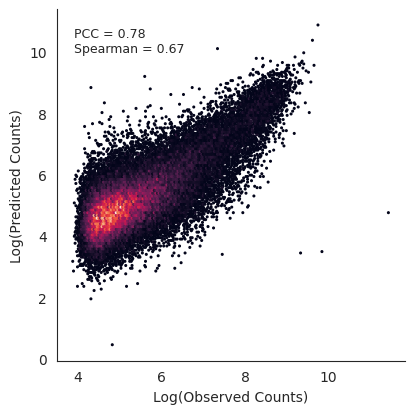

Exception ignored in atexit callback: <bound method InteractiveShell.atexit_operations of <ipykernel.zmqshell.ZMQInteractiveShell object at 0x1555512f7bd0>>
Traceback (most recent call last):
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3952, in atexit_operations
    self._atexit_once()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3935, in _atexit_once
    self.history_manager.end_session()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/history.py", line 592, in end_session
    self.writeout_cache()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/decorator.py", line 232, in fun
    return caller(func, *(extras + args), **kw)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/cellar/users/aklie/opt/miniconda3/envs/eug

In [ ]:
# Set up figure
fig, ax = plt.subplots(1, 1, figsize=(4.25, 4.25))

# Replace KDE with hexbin
ax.hexbin(
    df["y"],
    df["y_0"],
    gridsize=200,
    mincnt=1,
    alpha=1
)

# Pearson r and spearman r
pcc_val, pcc_pval = pearsonr(df["y_0"], df["y"])
spearman_val, spearman_pval = spearmanr(df["y_0"], df["y"])

# Clean up plot
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Log(Observed Counts)")
ax.set_ylabel("Log(Predicted Counts)")

# Top left annotation with stats
ax.text(
    0.05, 0.95,
    f"PCC = {pcc_val:.2f}\nSpearman = {spearman_val:.2f}",
    fontsize=9,
    transform=ax.transAxes,
    ha='left', va='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)

# Save figure
fig.tight_layout()
plt.savefig(os.path.join(path_out, "counts.pdf"), bbox_inches='tight', dpi=300)

# Profile